**EPL Goals Exploration - 5 Seasons of Premier League Data**

**#Overview**
This notebook explores 5 seasons of Premier League match data (2021,2026) sourced from football-data.co.uk
The goal is to understand the distribution of goals scored and test whether the Poisson distribution accurately describes real football data

**Data**: 1900 matches across 5 seasons

**Key Question**: Does EPL goal data follow a Poisson distribution?



In [19]:
import pandas as pd
import glob
import os
files = sorted(glob.glob('E0_*.csv'))
seasons = [pd.read_csv(f, encoding ='latin1') for f in files]
epl = pd.concat(seasons, ignore_index = True)
print(f'Total matches: {len(epl)}')
print()
print(f'Seasons loaded: {len(files)}')
print()
print(f'Columns available: {len(epl.columns)}')
print(f'\nFirst 10 columns:')
print(list(epl.columns[:10]))

Total matches: 1900

Seasons loaded: 5

Columns available: 163

First 10 columns:
['ï»¿Div', 'Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG']


In [7]:
#List -  a shelf with boxes that are numbered from 0. Order matters, and duplicates can be stored. shelves = [] 
#Item - one singke box on the shelf
#DataFrame - an excel sheet. Rows go down columns go across. 
#Object - a thing with data inside (attributes) and can make action(mean, sum etc) like a person with attributes and can do daily activities.




In [9]:
print(files)
print(type(files))

['E0_2022.csv', 'E0_2023.csv', 'E0_2024.csv', 'E0_2025.csv', 'E0_2026.csv']
<class 'list'>


In [20]:
#bracket rule
#() - calls a function
#[] - calls a column by its label or position, or is used for an argument.

In [11]:
# To see the 5 games of the first season only
seasons[0].head()

,ï»¿Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA
0,E0,13/08/2021,20:00,Brentford,Arsenal,2,0,H,1,0,...,1.62,0.50,1.75,2.05,1.81,2.13,2.05,2.17,1.80,2.09
1,E0,14/08/2021,12:30,Man United,Leeds,5,1,H,1,0,...,2.25,-1.00,2.05,1.75,2.17,1.77,2.19,1.93,2.10,1.79
2,E0,14/08/2021,15:00,Burnley,Brighton,1,2,A,1,0,...,1.62,0.25,1.79,2.15,1.81,2.14,1.82,2.19,1.79,2.12
3,E0,14/08/2021,15:00,Chelsea,Crystal Palace,3,0,H,2,0,...,1.94,-1.50,2.05,1.75,2.12,1.81,2.16,1.93,2.06,1.82
4,E0,14/08/2021,15:00,Everton,Southampton,3,1,H,0,1,...,1.67,-0.50,2.05,1.88,2.05,1.88,2.08,1.90,2.03,1.86


In [12]:
for i, season in enumerate(seasons):
    print(f'Season {i+1}: {len(season)} matches, {len(season.columns)} columns')

Season 1: 380 matches, 106 columns
Season 2: 380 matches, 106 columns
Season 3: 380 matches, 106 columns
Season 4: 380 matches, 120 columns
Season 5: 380 matches, 132 columns


**Home advantage. Does playing at home produce more goals and more wins?**


**Home and away goal average**

In [34]:
print('Avg home goals:', round(epl['FTHG'].mean(),3))
print('Avg away goals:', round(epl['FTAG'].mean(),3))
print('Total goals/match:', round((epl['FTHG'] + epl['FTAG']).mean(),3))

Avg home goals: 1.597
Avg away goals: 1.329
Total goals/match: 2.927


**Home and Away Result distribution**

In [49]:
print('Result distribution:')
print(epl['FTR'].value_counts(normalize = True).round(3))

Result distribution:
FTR
H    0.442
A    0.319
D    0.239
Name: proportion, dtype: float64


**Home and away win rate**

In [53]:
home_wins = (epl['FTR'] == 'H').mean()
away_wins = (epl['FTR'] == 'A').mean()
print(f'Home win rate: {home_wins:.1%}')
print(f'Away win rate: {away_wins:.1%}')

Home win rate: 44.2%
Away win rate: 31.9%


**Top-scoring home teams. Which teams score the most when playing at home?**

**Scoring habits while playing at home**

In [102]:
top_home = epl.groupby('HomeTeam') ['FTHG'].mean()
print(top_home)

HomeTeam
Arsenal             2.231579
Aston Villa         1.852632
Bournemouth         1.302632
Brentford           1.673684
Brighton            1.536842
Burnley             0.964912
Chelsea             1.705263
Crystal Palace      1.347368
Everton             1.231579
Fulham              1.565789
Ipswich             0.736842
Leeds               1.298246
Leicester           1.263158
Liverpool           2.315789
Luton               1.473684
Man City            2.705263
Man United          1.694737
Newcastle           1.968421
Norwich             0.631579
Nott'm Forest       1.315789
Sheffield United    1.000000
Southampton         0.964912
Sunderland          1.315789
Tottenham           1.789474
Watford             0.894737
West Ham            1.473684
Wolves              1.168421
Name: FTHG, dtype: float64


**Top 10 scoring teams at home**

In [108]:
print('Top 10 scoring home teams:')
print()
print(top_home.sort_values(ascending=False).head(10).round(2))

Top 10 scoring home teams:

HomeTeam
Man City       2.71
Liverpool      2.32
Arsenal        2.23
Newcastle      1.97
Aston Villa    1.85
Tottenham      1.79
Chelsea        1.71
Man United     1.69
Brentford      1.67
Fulham         1.57
Name: FTHG, dtype: float64


**Real Goals vs Poisson Model**

**Fitting a Poisson distribution to real EPL goals and comparing visually**

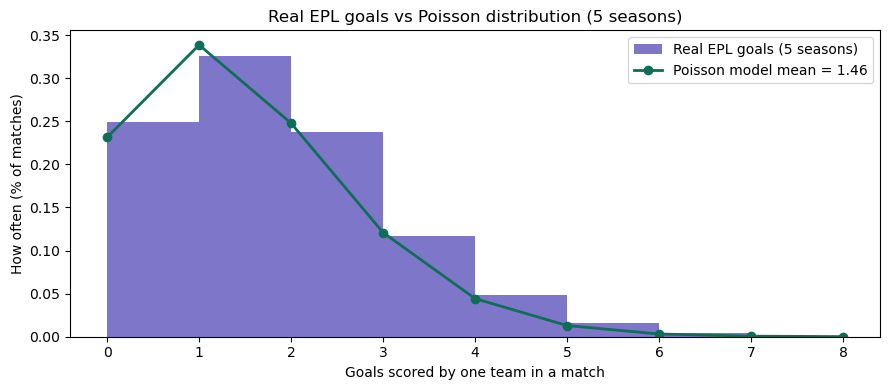

Average goals per team per match: 1.46


In [96]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
fig,ax = plt.subplots(figsize = (9,4))
#Real EPL goals gotten by combining home goals and away goals
all_goals = pd.concat([epl['FTHG'],epl['FTAG']])
ax.hist(all_goals, bins = range(0,9), density = True, alpha = 0.75, color = '#534AB7', label = 'Real EPL goals (5 seasons)')

#Fitted Poisson Overlay
lam = all_goals.mean()
x = np.arange(0,9)
ax.plot(x, stats.poisson.pmf(x,lam), 'o-', color = '#0F6E56', linewidth = 2, label = f'Poisson model mean = {lam:.2f}')
ax.set_xlabel('Goals scored by one team in a match')
ax.set_ylabel('How often (% of matches)')
ax.legend()
ax.set_title('Real EPL goals vs Poisson distribution (5 seasons)')
plt.tight_layout()
plt.savefig('epl_poisson_fit.png', dpi = 150)
plt.show()
print(f'Average goals per team per match: {lam:.2f}')

**FINDINGS**

Real EPL goals follow the Poisson Distribution closely (λ = 1.46 goals per team per match). The slight divergence at 0 goals where real data exceeds the Poisson prediction is consistent with Dixon-Coles correction which adjusts for the excesses of 0-0 draws in real football.